In [1]:
import earthaccess
import xarray as xr
import netCDF4, os, re, copy, glob
import numpy as np
import matplotlib.pyplot as plt
import pickle
import cartopy
import sys,os,glob,datetime
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.ticker as mticker
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import seaborn as sns
import datetime
import PACE_Util
from matplotlib.colors import ListedColormap

import warnings
warnings.filterwarnings("ignore")

### Download Data  

In [2]:
auth = earthaccess.login(persist=True)

In [3]:
# results = earthaccess.search_datasets(instrument="harp2")
# for item in results:
#     summary = item.summary()
#     print(summary["short-name"])

In [4]:
results = earthaccess.search_data(
    short_name="PACE_HARP2_L2_CLOUD_GPC", 
    # temporal=("2025-07-01", "2025-07-31"),
    temporal=("2025-07-06T19:20:50", "2025-07-06T19:25:49"),
    count=1
)
print(len(results))

In [6]:
files = earthaccess.download(results, "/umbc/rs/pi_zzbatmos/common/Data/PACE/PACE_HARP2_L2_CLOUD_GPC_v3_0")

### Load HARP-2 and OCI cloud retrievals

In [2]:
PACE_data_path = '/umbc/rs/pi_zzbatmos/common/Data/PACE/'
PACE_OCI_CLD_ANC_Level1C_path = 'PACE_OCI_CLD_ANC_Level-1C/'
HARP2_CLD_path = 'PACE_HARP2_L2_hipp/'

In [3]:
def extract_timestamps(file_paths):
    # Regular expression to match the timestamp (YYYYMMDDTHHMMSS)
    pattern = r'\d{8}T\d{6}'
    
    # List to store extracted timestamps
    timestamps = []
    for path in file_paths:
        # Search for the timestamp in the file path
        match = re.search(pattern, path)
        if match:
            timestamps.append(match.group(0))
    
    return timestamps

### Find all the HARP-2 cloud retrieval files and the corresponding OCI cloud files

In [4]:
HARP2_CLD_files=glob.glob(os.path.join(PACE_data_path, HARP2_CLD_path, '*.nc'))
HARP2_CLD_timestamp = extract_timestamps(HARP2_CLD_files)

In [5]:
# List to store pairs of matching HARP2 and OCI file paths
OCI_CLD_files = []

# Create a dictionary to map timestamps to HARP2 file paths for easy lookup
timestamp_to_harp2 = dict(zip(HARP2_CLD_timestamp, HARP2_CLD_files))

# List to store timestamps that have matching OCI files
kept_timestamps = []

# Search for matching OCI files
for timestamp in HARP2_CLD_timestamp:
    # Search for OCI files with the same timestamp
    oci_files = glob.glob(os.path.join(PACE_data_path, PACE_OCI_CLD_ANC_Level1C_path, f'*{timestamp}*.nc'))
    
    # If matching OCI files are found, store the pair
    if oci_files:
        harp2_file = timestamp_to_harp2[timestamp]
        for oci_file in oci_files:
            OCI_CLD_files.append((oci_file))
        kept_timestamps.append(timestamp)

# Update HARP2_CLD_timestamp to only include timestamps with matching OCI files
HARP2_CLD_timestamp[:] = kept_timestamps

# Trim HARP2_CLD_files to only include files with timestamps in kept_timestamps
HARP2_CLD_files[:] = [file for file in HARP2_CLD_files if any(timestamp in file for timestamp in kept_timestamps)]

In [6]:
print(len(kept_timestamps), len(HARP2_CLD_files), len(OCI_CLD_files))

2 2 2


## A case study

In [7]:
target_timestamp='20251002T182635'
idx = kept_timestamps.index(target_timestamp)
print(idx)

0


In [8]:
HARP2_CLD = PACE_Util.HARP2_L2_CLD(target_timestamp,os.path.join(PACE_data_path, HARP2_CLD_path))

In [9]:
OCI_CLD =  PACE_Util.OCI_CLD_ANC(target_timestamp,os.path.join(PACE_data_path, PACE_OCI_CLD_ANC_Level1C_path))

### Plot the HARP-2 Cloud Effective Radius retrieval

In [10]:
y0,x0 = 260,340
y1,x1 = 295,310
# y2,x2 = 350,405
y2,x2 = 343,413

CER of pixel 1: nan μm
CER of pixel 2: 5.49 μm
CER of pixel 3: 3.47 μm


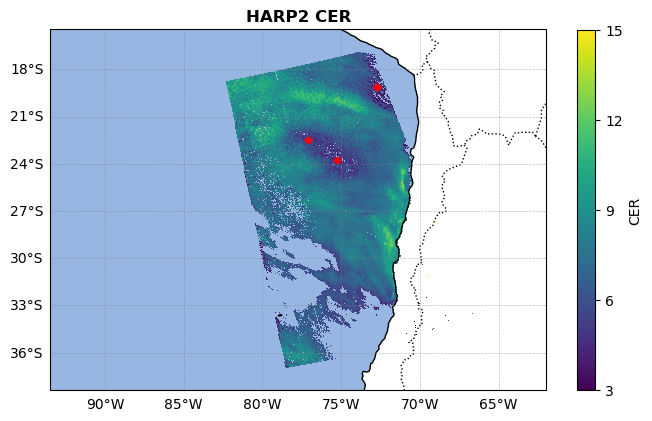

In [11]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
cmap_name='viridis'

HARP2_CER = HARP2_CLD.retr.cloud_bow_droplet_effective_radius

mat = ax.pcolormesh(HARP2_CLD.geo.longitude, HARP2_CLD.geo.latitude, HARP2_CER, transform=ccrs.PlateCarree(),
                    vmin=3, vmax=15, cmap=cmap_name, shading="nearest", rasterized=True)

ax.plot(HARP2_CLD.geo.longitude[y0, x0], HARP2_CLD.geo.latitude[y0, x0], marker='o', color='r', markersize=4, 
        transform=ccrs.PlateCarree())
print(f'CER of pixel 1: {HARP2_CER[y0,x0]:.2f} μm')

ax.plot(HARP2_CLD.geo.longitude[y1, x1], HARP2_CLD.geo.latitude[y1, x1], marker='*', color='r', markersize=6, 
        transform=ccrs.PlateCarree())
print(f'CER of pixel 2: {HARP2_CER[y1,x1]:.2f} μm')

ax.plot(HARP2_CLD.geo.longitude[y2, x2], HARP2_CLD.geo.latitude[y2, x2], marker='D', color='r', markersize=4, 
        transform=ccrs.PlateCarree())
print(f'CER of pixel 3: {HARP2_CER[y2,x2]:.2f} μm')

ax.set_aspect("equal")
# ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.set_title('HARP2 CER', fontsize=12, color='k', fontweight='bold')
gl= ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

cax = plt.colorbar(mat, ax=ax, ticks=np.arange(3, 16, 3), shrink=0.78, label="CER")

### Plot the Cloud Bow Effective Variance retrieval

CEV of pixel 1: nan
CEV of pixel 2: 0.03
CEV of pixel 3: 0.4975


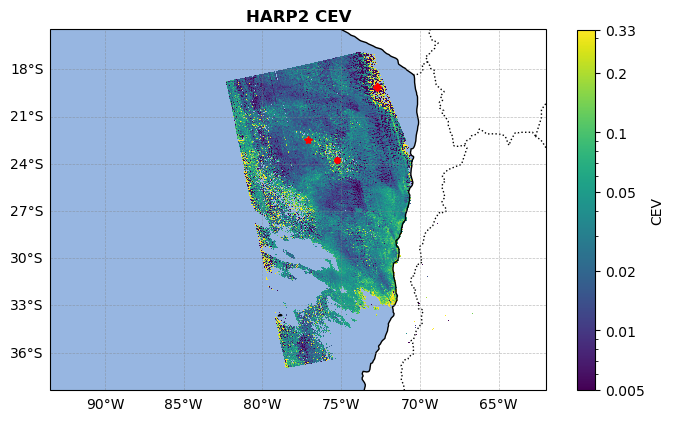

In [12]:
from matplotlib.colors import LogNorm

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
cmap_name='viridis'

HARP2_CEV = HARP2_CLD.retr.cloud_bow_droplet_effective_variance

mat = ax.pcolormesh(HARP2_CLD.geo.longitude, HARP2_CLD.geo.latitude, HARP2_CEV, transform=ccrs.PlateCarree(),
                     cmap=cmap_name, norm=LogNorm(vmin=0.005, vmax=0.33), shading="nearest", rasterized=True)

ax.plot(HARP2_CLD.geo.longitude[y0, x0], HARP2_CLD.geo.latitude[y0, x0], marker='o', color='r', markersize=4, 
        transform=ccrs.PlateCarree())
print(f'CEV of pixel 1: {HARP2_CEV[y0,x0]:.2f}')

ax.plot(HARP2_CLD.geo.longitude[y1, x1], HARP2_CLD.geo.latitude[y1, x1], marker='*', color='r', markersize=6, 
        transform=ccrs.PlateCarree())
print(f'CEV of pixel 2: {HARP2_CEV[y1,x1]:.2f}')

ax.plot(HARP2_CLD.geo.longitude[y2, x2], HARP2_CLD.geo.latitude[y2, x2], marker='D', color='r', markersize=4, 
        transform=ccrs.PlateCarree())
print(f'CEV of pixel 3: {HARP2_CEV[y2,x2]:.4f}')

ax.set_aspect("equal")
# ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.set_title('HARP2 CEV', fontsize=12, color='k', fontweight='bold')
gl= ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

cbar = plt.colorbar(mat, ax=ax, shrink=0.78)

ticks = [0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.33]
cbar.set_ticks(ticks)
cbar.set_ticklabels([str(t) for t in ticks])

cbar.set_label('CEV')

### Plot the OCI Cloud effective radius retrieval

CER of pixel 1: nan μm
CER of pixel 2: 6.97 μm
CER of pixel 3: 7.99 μm


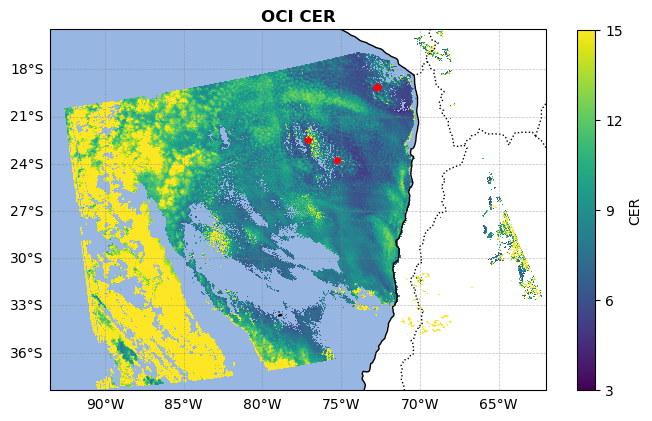

In [13]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
cmap_name='viridis'

OCI_CER = OCI_CLD.ds.cer_21_water_cloud.values

mat = ax.pcolormesh(OCI_CLD.ds.longitude, OCI_CLD.ds.latitude, OCI_CER, transform=ccrs.PlateCarree(), 
                    cmap=cmap_name, vmin=3, vmax=15, shading="nearest", rasterized=True)

ax.plot(HARP2_CLD.geo.longitude[y0, x0], HARP2_CLD.geo.latitude[y0, x0], marker='o', color='r', markersize=4, 
        transform=ccrs.PlateCarree())
print(f'CER of pixel 1: {OCI_CER[y0,x0]:.2f} μm')

ax.plot(HARP2_CLD.geo.longitude[y1, x1], HARP2_CLD.geo.latitude[y1, x1], marker='*', color='r', markersize=6, 
        transform=ccrs.PlateCarree())
print(f'CER of pixel 2: {OCI_CER[y1,x1]:.2f} μm')

ax.plot(HARP2_CLD.geo.longitude[y2, x2], HARP2_CLD.geo.latitude[y2, x2], marker='D', color='r', markersize=4, 
        transform=ccrs.PlateCarree())
print(f'CER of pixel 3: {OCI_CER[y2,x2]:.2f} μm')
        
ax.set_aspect("equal")
# ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.set_title('OCI CER', fontsize=12, color='k', fontweight='bold')
gl= ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

cax = plt.colorbar(mat, ax=ax, ticks=np.arange(3, 16, 3), shrink=0.78, label="CER")
# plt.savefig("Map_OCI.png", dpi=500, bbox_inches="tight")

In [14]:
HARP2_CLD.retr.cloud_bow_droplet_effective_radius.shape

(395, 519)

In [15]:
OCI_CLD.ds.cer_21_water_cloud.shape

(395, 519)